# Stage 6 — Earth pair and label generation

_Pipeline stage 6 of 14. This is the self-contained deep dive for the stage: narrative + analysis + interpretation, using the canonical `channel_heads` package and on-disk artifacts. Heavy rebuilds run via the `channel-heads` CLI (commands are given inline)._

## Pairs, the touching label, and the geometry the model learns

For every outlet we take **first-meet pairs** of channel heads — the two heads that
first meet going downstream at a confluence. The label `y = touching` is a *geometric*
test: do the two heads' contributing pixels touch (8-connectivity)? Trivial negatives
(impossibly far apart) are removed by `filter_hard_negatives`, and negatives are
subsampled to ~3:1. Here we look at what actually separates the classes — both in the
5 scalar features and in the **real confluence geometry**.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
MARS_DIR = ROOT / 'data/Mars'
REGIMES_ = ['regA', 'regB', 'regC']
RC = {'regA': '#e41a1c', 'regB': '#377eb8', 'regC': '#4daf4a'}
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
def _load_op_thr(r):  # per-regime operating threshold, read from disk (auto-tracks retrains)
    p = MODELS / f'optimal_threshold_geom_plus_cnn_emb_{r}.txt'
    return float(p.read_text().strip()) if p.exists() else float('nan')
OP_THR = {r: _load_op_thr(r) for r in REGIMES_}
def _abs(p):
    p = Path(p); return p if p.is_absolute() else ROOT / p
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


### 1 · Class balance and feature separation

regA: 22292 pairs | 7055 touching (31.6%)


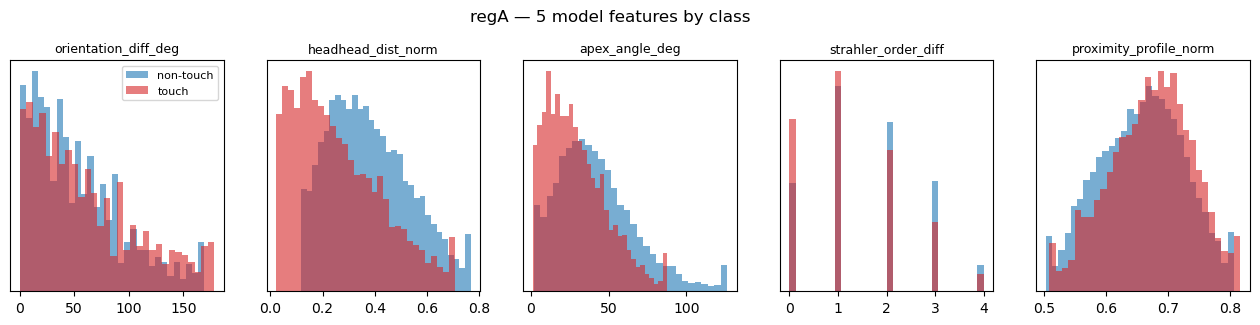

In [2]:
d = pd.read_csv(RESULTS_DIR / 'master_dataset_regA.csv')
print('regA:', len(d), 'pairs |', int(d.y.sum()), 'touching (%.1f%%)' % (100*d.y.mean()))
fig, axes = plt.subplots(1, len(MODEL_FEATURES), figsize=(16, 3))
for ax, feat in zip(axes, MODEL_FEATURES):
    for lbl, col, nm in [(0, '#1f77b4', 'non-touch'), (1, '#d62728', 'touch')]:
        v = d.loc[d.y == lbl, feat].dropna(); lo, hi = v.quantile([0.01, 0.99])
        ax.hist(v.clip(lo, hi), bins=30, alpha=0.6, color=col, density=True, label=nm)
    ax.set_title(feat, fontsize=9); ax.set_yticks([])
axes[0].legend(fontsize=8); plt.suptitle('regA — 5 model features by class', y=1.05); plt.show()

### 2 · Feature correlations (are the 5 features redundant?)

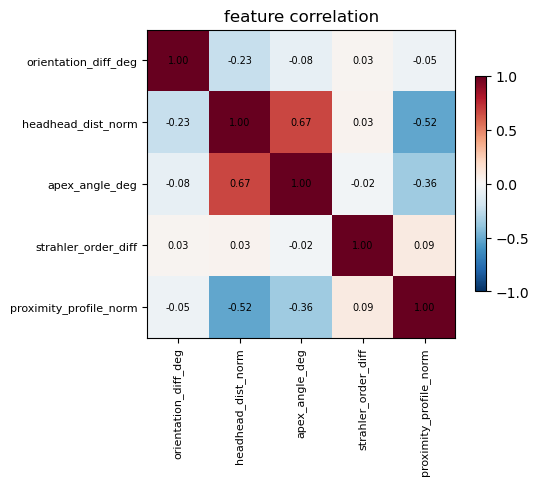

In [3]:
import numpy as np
corr = d[MODEL_FEATURES].corr()
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(5)); ax.set_xticklabels(MODEL_FEATURES, rotation=90, fontsize=8)
ax.set_yticks(range(5)); ax.set_yticklabels(MODEL_FEATURES, fontsize=8)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, shrink=0.7); ax.set_title('feature correlation'); plt.show()

### 3 · Real confluence geometry — touching vs non-touching

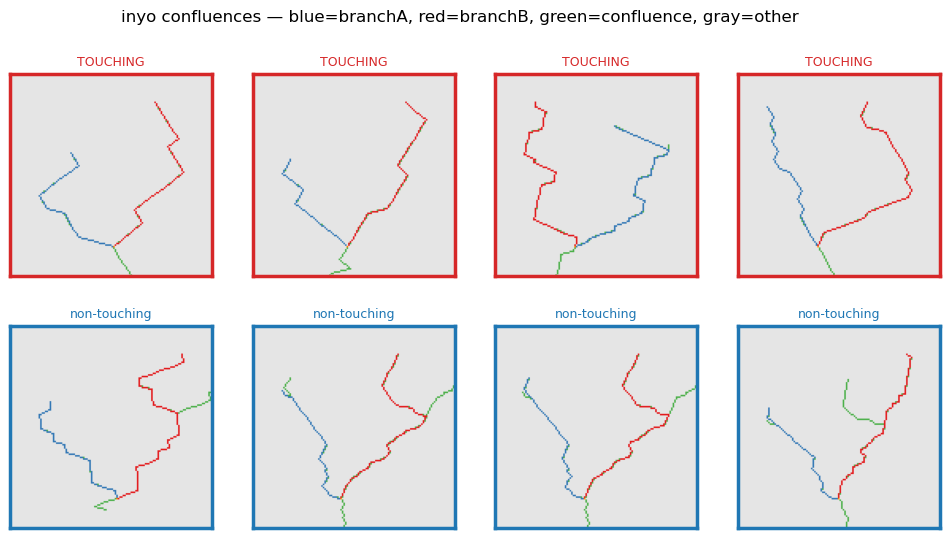

In [4]:
# Rebuild one basin's REGIME-PRUNED network (so the pair node IDs resolve)
# and rasterize a few real pairs.
from channel_heads.training.regime import make_regime_stream_loader
from channel_heads.units import km2_to_cells
from channel_heads.rasterization.earth_patches import rasterize_outlet_pair
from channel_heads.regimes import REGIMES
from channel_heads.basin_config import get_basin_config
from matplotlib.colors import ListedColormap
BASIN = 'inyo'; regime = REGIMES['regA']
cfg = get_basin_config(BASIN); lat, z_th = cfg['lat'], cfg['z_th']
loader = make_regime_stream_loader(regime)
res = loader(BASIN, lat=lat, z_th=z_th, threshold=km2_to_cells(regime.threshold_km2, lat))
db = d[d.basin == BASIN]
cmap = ListedColormap([[0.9,0.9,0.9],[0.20,0.47,0.71],[0.89,0.10,0.11],[0.30,0.69,0.29],[1.0,0.5,0.0]])
if res is not None and not db.empty:
    s, dem = res; gs = dem.shape if hasattr(dem, 'shape') else dem.z.shape
    samp = pd.concat([db[db.y==1].head(4), db[db.y==0].head(4)])
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for ax, (_, row) in zip(axes.ravel(), samp.iterrows()):
        try:
            patch = rasterize_outlet_pair(s, int(row.outlet), int(row.head_1), int(row.head_2),
                                          int(row.confluence), gs, target_size=128)
            ax.imshow(patch, cmap=cmap, vmin=0, vmax=4)
        except Exception as ex:
            ax.text(0.5, 0.5, str(ex)[:40], fontsize=6, ha='center')
        c = '#d62728' if row.y == 1 else '#1f77b4'
        ax.set_title('TOUCHING' if row.y == 1 else 'non-touching', color=c, fontsize=9)
        for sp in ax.spines.values(): sp.set_edgecolor(c); sp.set_linewidth(2.5)
        ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle(f'{BASIN} confluences — blue=branchA, red=branchB, green=confluence, gray=other'); plt.show()
else:
    print('stream load / basin rows unavailable')

**Takeaway.** Touching pairs trend toward smaller orientation contrast and shorter
normalized head-to-head distance — coupled heads sit closer and more aligned. The
features are only weakly correlated (each adds information), but none separates the
classes alone, and the *shape* of the meeting (panel 3) carries signal the scalars
miss. That motivates both a learned classifier and the CNN shape-context of Stage 7-8.